# Epistasis

If $\xi[i, j]$ is the expression shift of a pairwise, $(i,j)$ mutation, then the epistasis effect is given by the following.
$$
\eta_{i,j} = \xi_{i,j}- \xi_i - \xi_{j}
$$

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from promdis.processing import get_sequence_arrays_and_counts, gene_seq_to_array
from promdis.core import compute_mean_expression_shift
from promdis.core import compute_expression_shift_by_mutation
from promdis.core import compute_expression_shift_by_pairwise_mutation
from promdis.core import compare_sequences
from promdis.pl import plot_data_2d

In [2]:
OUTDIR = "../results/epistasis"

os.makedirs(OUTDIR, exist_ok=True)

SEED = None
rng = np.random.default_rng(seed=SEED)

Load data and compute expression values.

In [3]:
FPATH = "../data/expression_data/ykgE_dataset_combined.csv"

df = pd.read_csv(FPATH)
df['barcode'] = df['seq'].str.slice(160,)
df['promoter'] = df['seq'].str.slice(0, 160)
df

seqs, counts_dna, counts_rna = get_sequence_arrays_and_counts(
    df, key_promoter='promoter', key_rna='ct_1', key_dna='ct_0'
)

expression = counts_rna / (counts_dna + counts_rna)

In [4]:
# Load wildtype data

GENE = 'ykgE'

WT_GENES_FPATH = "../data/wtsequences.csv"

wildtype_genes_df = pd.read_csv(WT_GENES_FPATH)

WT_GENE_SEQUENCES = {
    g: wildtype_genes_df.loc[wildtype_genes_df['name'] == g,'geneseq'].values[0]
    for g in wildtype_genes_df['name'].unique()
}

GENE_WT_SEQ = WT_GENE_SEQUENCES[GENE]

nbases = len(GENE_WT_SEQ)
print(f"{GENE} wildtype sequence (length {nbases}):\n", GENE_WT_SEQ)

wt_seq = gene_seq_to_array(GENE_WT_SEQ)

ykgE wildtype sequence (length 160):
 TCGATTTCCCCATAAAATGTGAGCGATGCCGAAAGAAATAAAATTAGTTATTGCATTTGACGTTTGGATGAAAGATTATCATTTGTCATACAAATGAGGGGTGGTATGTTGCTAGCCAATTAAAAAAGAACGCCATATTTATTGATGATTGATCCCCCGG


## Computing Epistasis

In [5]:
SEGMENT_SIZE = 1

Below, we compute epistasis by taking the difference between the mean exression shift when both segments are mutated and the mean expression shift when only one segment is mutated.
We compute the first expression shift value by considering all sequences with exactly one mutation across both segments in a pair, and the second expression shift value by considering all sequences with exactly two mutations across both segments, with one mutation on each.
The epistasis value $\eta_1$ is then found by computing $\eta_1= \xi_{i,j} - 2\xi_{i}$

/Users/addisonhowe/Documents/Projects/promoter-dissection/promdis/core.py:478: RuntimeWarning: invalid value encountered in divide
  mean_expression = total_expression / counts


eta is symmetric? True


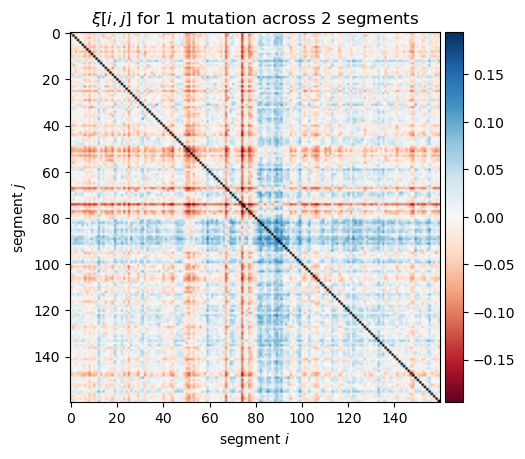

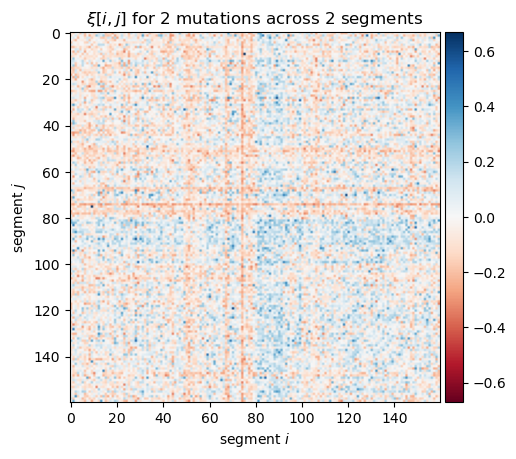

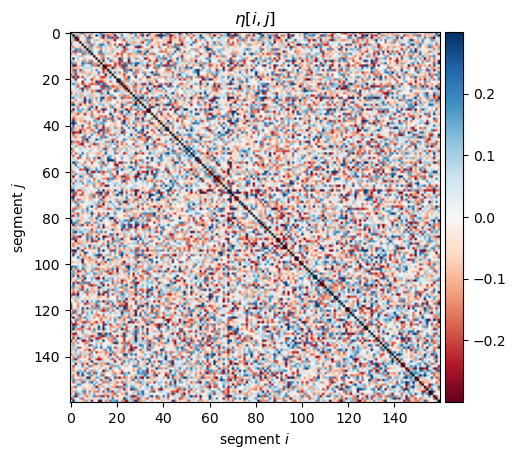

In [6]:
if SEGMENT_SIZE == 2:
    profile_groups = [
        [((0,1),(0,0)),((1,0),(0,0)),((0,0),(1,0)),((0,0),(0,1))], # 1 mutation
        [((0,1),(0,1)),((1,0),(1,0)),((0,1),(1,0)),((1,0),(0,1))], # 2 mutations
    ]
elif SEGMENT_SIZE == 1:
    profile_groups = [
        [((1,),(0,)), ((0,),(1,))], # 1 mutation
        [((1,),(1,))],              # 2 mutations
    ]
else:
    raise RuntimeError(f"Can't handle SEGMENT_SIZE={SEGMENT_SIZE}")

(xi_double_1mut, xi_double_2mut), _ = compute_expression_shift_by_pairwise_mutation(
    seqs, expression, wt_seq,
    segment_size=SEGMENT_SIZE,
    profile_groups=profile_groups
)

# All instances with one mutation across two segments. 
ax = plot_data_2d(
    xi_double_1mut,
    cmap='RdBu',
)
ax.set_title("$\\xi[i,j]$ for 1 mutation across 2 segments")
plt.savefig(f"{OUTDIR}/v1_x1_single.pdf")

# All instances with one mutation at each position. 
ax = plot_data_2d(
    xi_double_2mut,
    cmap='RdBu',
)
ax.set_title("$\\xi[i,j]$ for 2 mutations across 2 segments")
plt.savefig(f"{OUTDIR}/x1_xi_double.pdf")

# Difference between two-segment mutations and *two* one-segment mutations
eta_v1 = xi_double_2mut - 2 * xi_double_1mut
ax = plot_data_2d(
    eta_v1,
    cmap='RdBu',
    vmax=0.3,
)
ax.set_title("$\\eta[i,j]$")
plt.savefig(f"{OUTDIR}/v1_eta.pdf")

print("eta is symmetric?", np.allclose(eta_v1, eta_v1.T, equal_nan=True));

Below, a similar calculation is performed, but now explicitly calculating $\xi_i$ and $\xi_j$ independently, and computing $\eta_2=\xi_{i,j}-\xi_i - \xi_j$.

/Users/addisonhowe/Documents/Projects/promoter-dissection/promdis/core.py:478: RuntimeWarning: invalid value encountered in divide
  mean_expression = total_expression / counts


eta is symmetric?  True


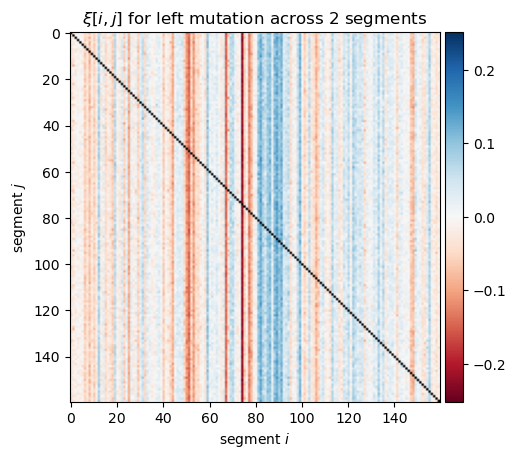

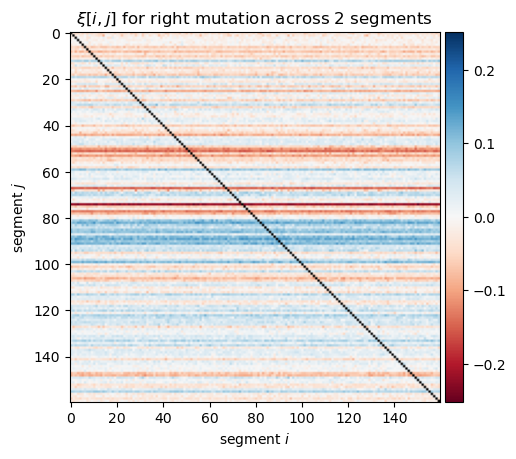

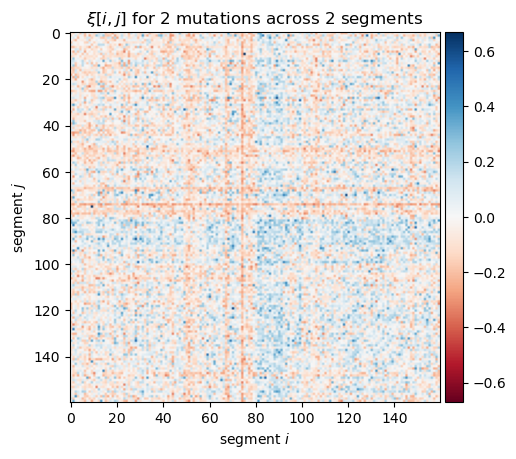

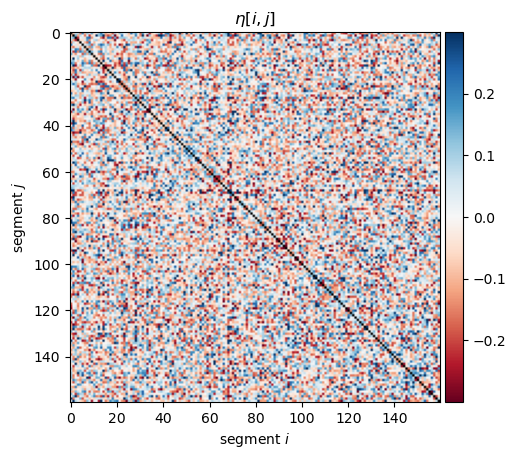

In [7]:
if SEGMENT_SIZE == 2:
    profile_groups = [
        [((0,1),(0,0)),((1,0),(0,0))], # 1 mutation (left)
        [((0,0),(1,0)),((0,0),(0,1))], # 1 mutation (right)
        [((0,1),(0,1)),((1,0),(1,0)),((0,1),(1,0)),((1,0),(0,1))], # 2 mutations
    ]
elif SEGMENT_SIZE == 1:
    profile_groups = [
        [((1,),(0,))], # 1 mutation (left)
        [((0,),(1,))], # 1 mutation (right)
        [((1,),(1,))], # 2 mutations
    ]
else:
    raise RuntimeError(f"Can't handle SEGMENT_SIZE={SEGMENT_SIZE}")

(xi_1mut_left, xi_1mut_right, xi_2mut), _ = compute_expression_shift_by_pairwise_mutation(
    seqs, expression, wt_seq,
    segment_size=SEGMENT_SIZE,
    profile_groups=profile_groups
)

# All instances with left mutation across two segments. 
ax = plot_data_2d(
    xi_1mut_left,
    cmap='RdBu',
)
ax.set_title("$\\xi[i,j]$ for left mutation across 2 segments")
plt.savefig(f"{OUTDIR}/v2_xi_single_left.pdf")

# All instances with right mutation across two segments. 
ax = plot_data_2d(
    xi_1mut_right,
    cmap='RdBu',
)
ax.set_title("$\\xi[i,j]$ for right mutation across 2 segments")
plt.savefig(f"{OUTDIR}/v2_xi_single_right.pdf")

# All instances with one mutation at each position. 
ax = plot_data_2d(
    xi_2mut,
    cmap='RdBu',
)
ax.set_title("$\\xi[i,j]$ for 2 mutations across 2 segments")
plt.savefig(f"{OUTDIR}/v2_xi_double.pdf")

# Difference between two-segment mutations and *two* one-segment mutations
eta_v2 = xi_double_2mut - xi_1mut_right - xi_1mut_left
ax = plot_data_2d(
    eta_v2,
    cmap='RdBu',
    vmax=0.3,
)
ax.set_title("$\\eta[i,j]$")
plt.savefig(f"{OUTDIR}/v2_eta.pdf")

print("eta is symmetric? ", np.allclose(eta_v2, eta_v2.T, equal_nan=True))

A third version of the computation, where we compute the single-mutation expression shift without any condition on a second segment.
This is computed as $\eta_3 = \xi_{i,j} - \xi_i - \xi_i^T$.
This is equivalent to the computation performed via the function `compute_total_expression_by_pairwise_bp_mutation` defined below.

eta is symmetric?  True


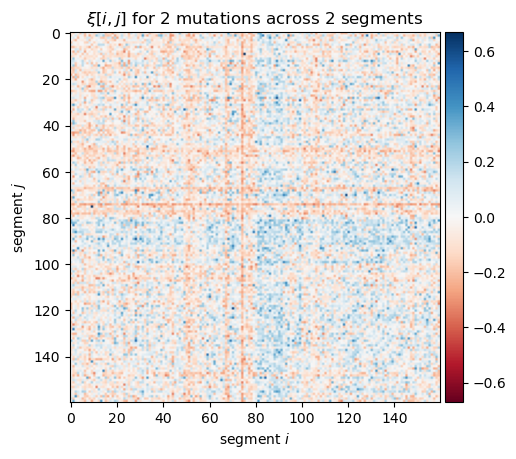

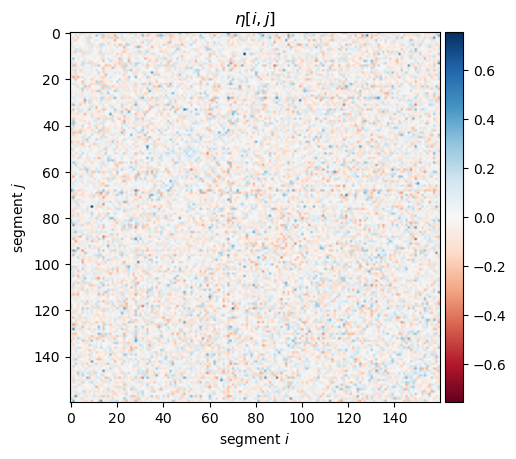

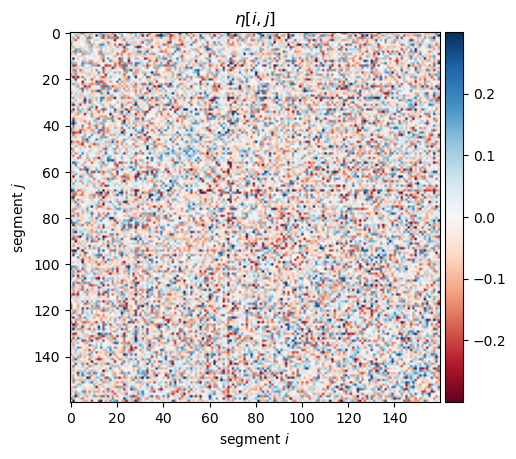

In [8]:
if SEGMENT_SIZE == 2:
    profile_group = [((0,1),(0,1)),((1,0),(1,0)),((0,1),(1,0)),((1,0),(0,1))]
elif SEGMENT_SIZE == 1:
    profile_group = [((1,),(1,))]
else:
    raise RuntimeError(f"Can't handle SEGMENT_SIZE={SEGMENT_SIZE}")

# All instances with one mutation on both segments.
xi_2mut, _ = compute_expression_shift_by_pairwise_mutation(
    seqs, expression, wt_seq,
    segment_size=SEGMENT_SIZE,
    profile_groups=profile_group
)

if SEGMENT_SIZE == 2:
    profile_group = [(0,1),(1,0)]
elif SEGMENT_SIZE == 1:
    profile_group = [(1,)]
else:
    raise RuntimeError(f"Can't handle SEGMENT_SIZE={SEGMENT_SIZE}")

# All instances with one mutation at a single position. 
xi1_mut, _ = compute_expression_shift_by_mutation(
    seqs, expression, wt_seq, 
    segment_size=SEGMENT_SIZE,
    profile_groups=profile_group
)

ax = plot_data_2d(
    xi_2mut,
    cmap='RdBu',
)
ax.set_title("$\\xi[i,j]$ for 2 mutations across 2 segments")
plt.savefig(f"{OUTDIR}/v3_xi_double.pdf")

# Difference between two-segment mutations and *two* one-segment mutations
eta_v3 = xi_2mut - xi1_mut[None,:] - xi1_mut[:,None]
ax = plot_data_2d(
    eta_v3,
    cmap='RdBu',
)
ax.set_title("$\\eta[i,j]$")
plt.savefig(f"{OUTDIR}/v3_eta.pdf")

ax = plot_data_2d(
    eta_v3,
    cmap='RdBu',
    vmax=0.3,
)
ax.set_title("$\\eta[i,j]$")
plt.savefig(f"{OUTDIR}/v3_eta_vmax_0.3.pdf")

print("eta is symmetric? ", np.allclose(eta_v3, eta_v3.T, equal_nan=True))

One final computation, which should be equivalent to the one done previously.

In [9]:
def compute_total_expression_by_pairwise_bp_mutation(
        sequences,
        expression,
        wt_seq,
):
    """Compute total expression and counts for each pairwise mutation of basepairs.
        Also compute pair-wise epistasis. 
    """
    nseqs, nbases = sequences.shape
    mut_screen = compare_sequences(sequences, wt_seq)

    mut_exp_by_idx = np.zeros([nbases, nbases])
    wt_exp_by_idx = np.zeros([nbases, nbases])
    counts_mut = np.zeros([nbases, nbases])
    counts_wt = np.zeros([nbases, nbases])
    eta = np.zeros([nbases, nbases])
    
    single_mut_shift = compute_mean_expression_shift(seqs, expression, wt_seq)
    for i in range(nbases):
        for j in range(nbases):
            for k in range(nseqs):
                if mut_screen[k][i] and mut_screen[k][j]:
                    mut_exp_by_idx[i][j] += expression[k]
                    counts_mut[i][j] += 1
                if not mut_screen[k][i] and not mut_screen[k][j]:
                    wt_exp_by_idx[i][j] += expression[k]
                    counts_wt[i][j] += 1
            eta[i][j] = single_mut_shift[i] + single_mut_shift[j]
                    
    exp_and_counts = [mut_exp_by_idx, counts_mut, wt_exp_by_idx, counts_wt]
    exp_shift_by_idx = mut_exp_by_idx / counts_mut - wt_exp_by_idx / counts_wt 
    eta = exp_shift_by_idx - eta 
    return exp_shift_by_idx, eta, exp_and_counts


In [10]:
exp_by_indx, eta_v4, exp_and_counts = compute_total_expression_by_pairwise_bp_mutation(
    seqs, expression, wt_seq
)

In [11]:
# Shows that this is equivalent to the computation performed above.
print("eta_v3 matches eta_v4?:", np.allclose(eta_v3, eta_v4))

print("Eta ranges:")
print("eta_v1:", np.nanmin(eta_v1), np.nanmax(eta_v1))
print("eta_v2:", np.nanmin(eta_v2), np.nanmax(eta_v2))
print("eta_v3:", np.nanmin(eta_v3), np.nanmax(eta_v3))
print("eta_v4:", np.nanmin(eta_v4), np.nanmax(eta_v4))

eta_v3 matches eta_v4?: True
Eta ranges:
eta_v1: -0.5407914544487288 0.7690752291218242
eta_v2: -0.528159229519801 0.7702428292618702
eta_v3: -0.46162224016422465 0.7545698275639101
eta_v4: -0.46162224016422515 0.7545698275639099


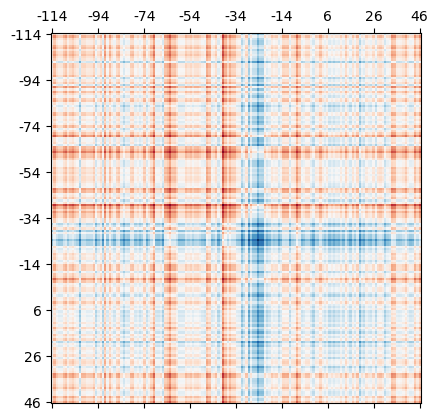

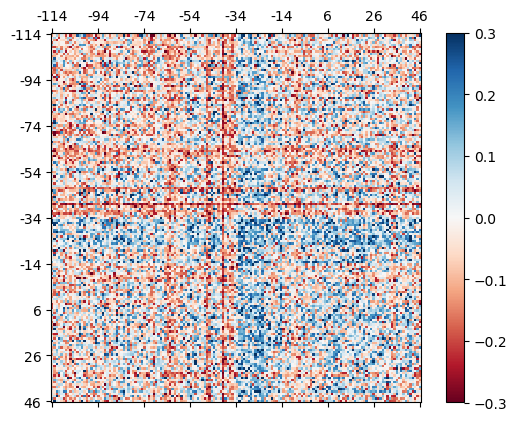

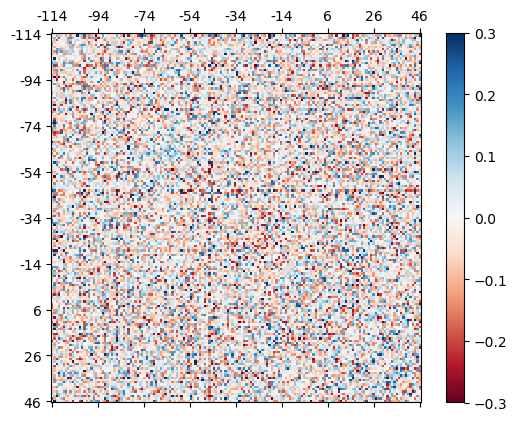

In [12]:
ticks = np.arange(-114, 47, 20)

# NOTE: Not averaged
fig, ax = plt.subplots()
cax = ax.matshow(exp_and_counts[0] - exp_and_counts[2], cmap='RdBu')
ax.set_xticks(np.linspace(0, 159, len(ticks)))
ax.set_xticklabels(ticks)
ax.set_yticks(np.linspace(0, 159, len(ticks)))
ax.set_yticklabels(ticks)
plt.savefig(f"{OUTDIR}/v4_unaveraged_xi.pdf")

fig, ax = plt.subplots()
cax = ax.matshow(exp_by_indx, cmap='RdBu', vmin = -0.3, vmax = 0.3)
ax.set_xticks(np.linspace(0, 159, len(ticks)))
ax.set_xticklabels(ticks)
ax.set_yticks(np.linspace(0, 159, len(ticks)))
ax.set_yticklabels(ticks)
fig.colorbar(cax)
plt.savefig(f"{OUTDIR}/v4_expression.pdf")

fig, ax = plt.subplots()
cax = ax.matshow(eta_v4, cmap='RdBu', vmin = -0.3, vmax = 0.3)
ax.set_xticks(np.linspace(0, 159, len(ticks)))
ax.set_xticklabels(ticks)
ax.set_yticks(np.linspace(0, 159, len(ticks)))
ax.set_yticklabels(ticks)
fig.colorbar(cax)
plt.savefig(f"{OUTDIR}/v4_eta.pdf")